In [1]:
from qiskit import *

# Definitions of the carry, carry inverse, and sum gates
#Carry converted to a custom gate
car = QuantumCircuit(4, name = 'Carry')
car.ccx(1,2,3)
car.cx(1,2)
car.ccx(0,2,3)
carry_gate = car.to_gate()

#Carry Inverse converted to a custom gate
carry_inv = QuantumCircuit(4, name = 'Carry Inverse')
carry_inv.ccx(0,2,3)
carry_inv.cx(1,2)
carry_inv.ccx(1,2,3)
car_inv_gate = carry_inv.to_gate()

#Sum converted to a custom gate
sum = QuantumCircuit(3, name = 'Sum')
sum.cx(1,2)
sum.cx(0,2)
sum_gate = sum.to_gate()

In [2]:
# Definition of the Addition Gate, if control = TRUE, the gate will be controlled by one qubit
def create_add_gate(n:int, control:bool = False):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    C = QuantumRegister(n,"c")
    
    add = QuantumCircuit(A,B,C, name= 'Add')

    # Subcircuit U_1 with a cascade of carry gates
    for qubit in range(n - 1):
        add.append(carry_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])

    # Subcircuit U_2
    add.append(carry_gate,[C[n-1], A[n-1],B[n-1],B[n]])
    add.cx(A[n-1], B[n-1])
    add.append(sum_gate,[C[n-1], A[n-1], B[n-1]])

    # Subcircuit U_3 with a cascade of sums and carry inverses
    for qubit in range(n - 1)[::-1]:
        add.append(car_inv_gate,[C[qubit],A[qubit],B[qubit],C[qubit+1]])
        add.append(sum_gate,[C[qubit], A[qubit], B[qubit]])
        
    if control:
      return add.to_gate().control(1) # Build a controlled Add gate if control = True
    else:
      return add.to_gate()  # Otherwise build an Add gate
       

In [3]:
# Definition of the Subtraction Gate, if control = TRUE, the gate will be controlled by one qubit
def create_subtraction_gate(n:int, control:bool = False):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    C = QuantumRegister(n,"c")

    sub = QuantumCircuit(A,B,C, name= 'Subtract')

    # Subcircuit U_3* with a cascade of sum and carry gates
    for qubit in range(n - 1):
        sub.append(sum_gate,[C[qubit], A[qubit], B[qubit]])
        sub.append(carry_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])

    # Subcircuit U_2*
    sub.append(sum_gate,[C[n-1], A[n-1], B[n-1]])    
    sub.cx(A[n-1], B[n-1])
    sub.append(car_inv_gate,[C[n-1], A[n-1], B[n-1], B[n]])    

    # Subcircuit U_1* with a cascade of carry inverses
    for qubit in range(n - 1)[::-1]:
        sub.append(car_inv_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])
        
    if control:
        return sub.to_gate().control(1) # Build a controlled Sub gate if control = True
    else:
        return sub.to_gate() # Otherwise, build a Sub gate

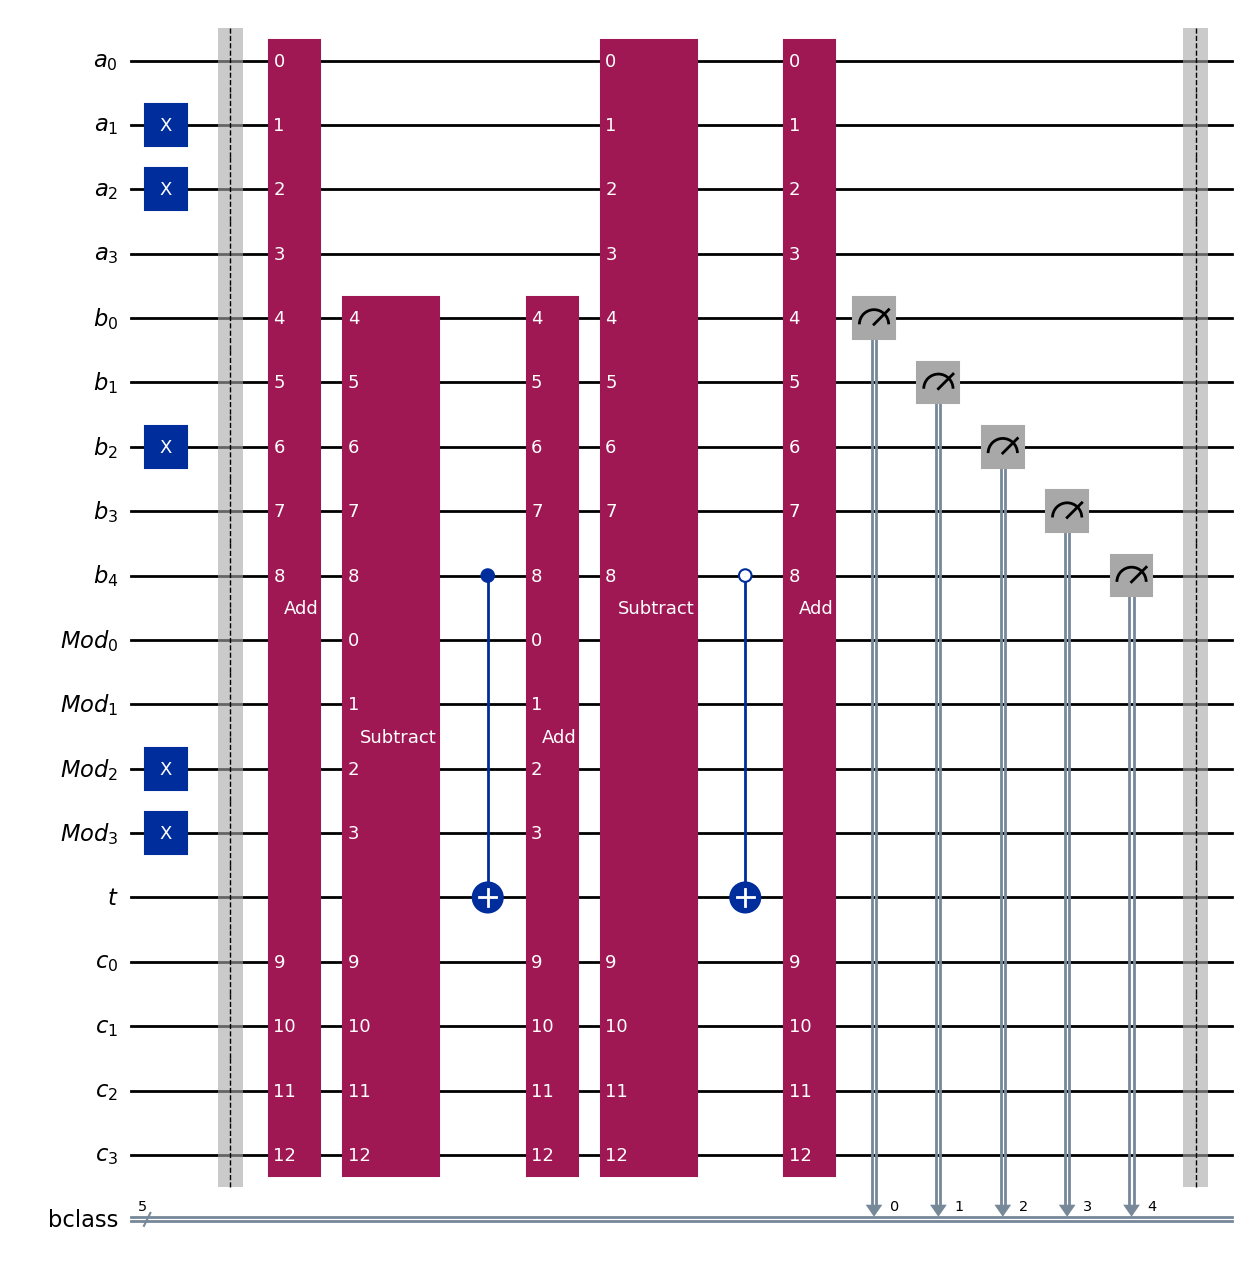

In [4]:
# Create an Add Mod M gate with n = 4 bits
n = 4
control = False
A = QuantumRegister(n,"a")
B = QuantumRegister(n + 1,"b")
M = QuantumRegister(n,"Mod")
T = QuantumRegister(1,"t")
C = QuantumRegister(n,"c")
B_C = ClassicalRegister(n + 1,"bclass") #measurement for output
#C_C = ClassicalRegister(n,"cclass") #measurement for Carry
#T_C = ClassicalRegister(1,"tclass") #measurement for the qubit t

seed_a = '0110' # Value (6) to store in register a
seed_b = '00100' # Value (4) to store in register b
                # Expected sum: 6 + 4 mod 12 = 10 = |00101>
seed_m = '01100' # Value (12) of M for arithmetic mod M

AddModCirc = QuantumCircuit(A,B,M,T,C,B_C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        AddModCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        AddModCirc.x(B[bit])

# Repeat the process for the initial value of register b
seed_m = list(map(int, list(seed_m)))[::-1] 

# encode the value of register b
for bit in range(len(seed_m)):
    if seed_m[bit] == 1:
        AddModCirc.x(M[bit])

AddModCirc.barrier()

# Create the Add, Controlled Add, and Sub gates:
AddGate = create_add_gate(n, control)
control = True
CtlAddGate = create_add_gate(n, control)
SubGate = create_subtraction_gate(n)

AddModCirc.append(AddGate,A[:]+B[:]+C[:]) # First sum A + B and save it in B
AddModCirc.append(SubGate,M[:]+B[:]+C[:]) # Subtract M from B
AddModCirc.cx(B[n],T) # Toggle T when underflow
AddModCirc.append(CtlAddGate,T[:]+M[:]+B[:]+C[:]) # When underflow, add M back to B
AddModCirc.append(SubGate,A[:]+B[:]+C[:]) # Subtract A froM B again
AddModCirc.cx(B[n],T, ctrl_state=0) # Toggle T when underflow
AddModCirc.append(AddGate, A[:]+B[:]+C[:]) # Construct final result

# Get the state of the data qubits.
AddModCirc.measure(B, B_C)
#AddModCirc.measure(C, C_C)
#AddModCirc.measure(T,T_C)
AddModCirc.barrier()

#draw the circuit.
AddModCirc.draw(output="mpl")



In [5]:
# Measure the value of t and the carry register in the n + 1 most significant qubits
# and the value of the register b in the n + 1 least significant qubits
from qiskit_aer.primitives import SamplerV2
 
sampler = SamplerV2()
job_simulator = sampler.run([AddModCirc.decompose(reps=6)], shots = 1024)

result_simulator = job_simulator.result()
counts = result_simulator[0].data.bclass.get_counts() #data."measure label"

print(counts)

{'01010': 1024}


In [6]:
from qiskit_aer import AerProvider, AerSimulator, QasmSimulator, StatevectorSimulator, UnitarySimulator
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options

#Load your IBM Quantum account(s)
service = QiskitRuntimeService(channel = "ibm_cloud")

In [7]:
backend = service.least_busy(simulator = False, operational = True)
print(backend)



<IBMBackend('ibm_fez')>


In [9]:
# Import the NoiseModel
from qiskit_aer.noise import NoiseModel

# Create the noise model based on the backend properties
noise_model = NoiseModel.from_backend(backend)
# Get coupling map from backend
coupling_map = backend.configuration().coupling_map
# Get basis gates from noise model
basis_gates = noise_model.basis_gates
# Get the Aer simulator to apply noise model
noisy_simulator = AerSimulator()

opt_level = 3
pass_manager = generate_preset_pass_manager(backend = noisy_simulator, optimization_level = opt_level)
isa_circuit = pass_manager.run(AddModCirc)


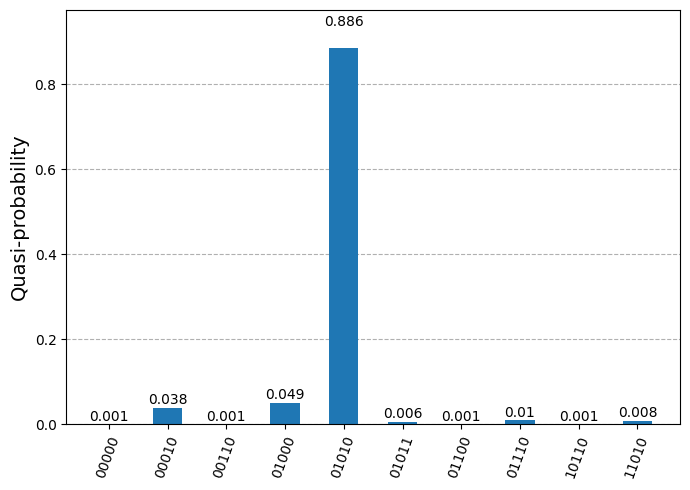

In [10]:
# Execute the circuit on the simulator with the backend properties, and generated noise model
result = noisy_simulator.run(isa_circuit, coupling_map = coupling_map, basis_gates = basis_gates, noise_model = noise_model).result()
# Obtain and print results
counts = result.get_counts()
plot_distribution(counts)

In [ ]:
#opt_level = 3
#pass_manager = generate_preset_pass_manager(backend = backend, optimization_level = opt_level)
#isa_circuit = pass_manager.run(AddModCirc)

#opt_level = 3
pass_manager = generate_preset_pass_manager(backend = backend)
isa_circuit = pass_manager.run(AddModCirc)

# Transpile the circuit
transpiled_qc = transpile(AddModCirc, backend)


In [ ]:
# Execute the circuit on the simulator with the backend properties, and generated noise model
result = noisy_simulator.run(isa_circuit, coupling_map = coupling_map, basis_gates = basis_gates, noise_model = noise_model).result()
# Obtain and print results
counts = result.get_counts()
plot_distribution(counts)

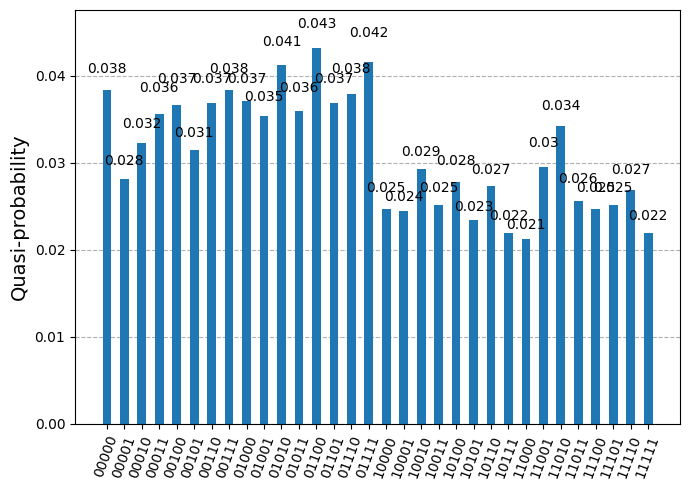

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

pass_manager = generate_preset_pass_manager(backend = backend, optimization_level = opt_level)
isa_circuit = pass_manager.run(AddModCirc)

sampler = Sampler(mode = backend)

result = sampler.run([isa_circuit]).result()

# Get results for the first (and only) PUB
pub_result = result[0]
counts = pub_result.data.bclass.get_counts()
plot_distribution(counts)

In [13]:
import numpy as np
from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager, InstructionDurations
from qiskit.transpiler.passes import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit.visualization import timeline_drawer

In [14]:
#Let's transpile and add specific scheduling and layout methods to the circuit we created at the start of this notebook 
#and view the default timeline
transpiled_qc = transpile(AddModCirc, backend, scheduling_method='alap', layout_method='trivial')

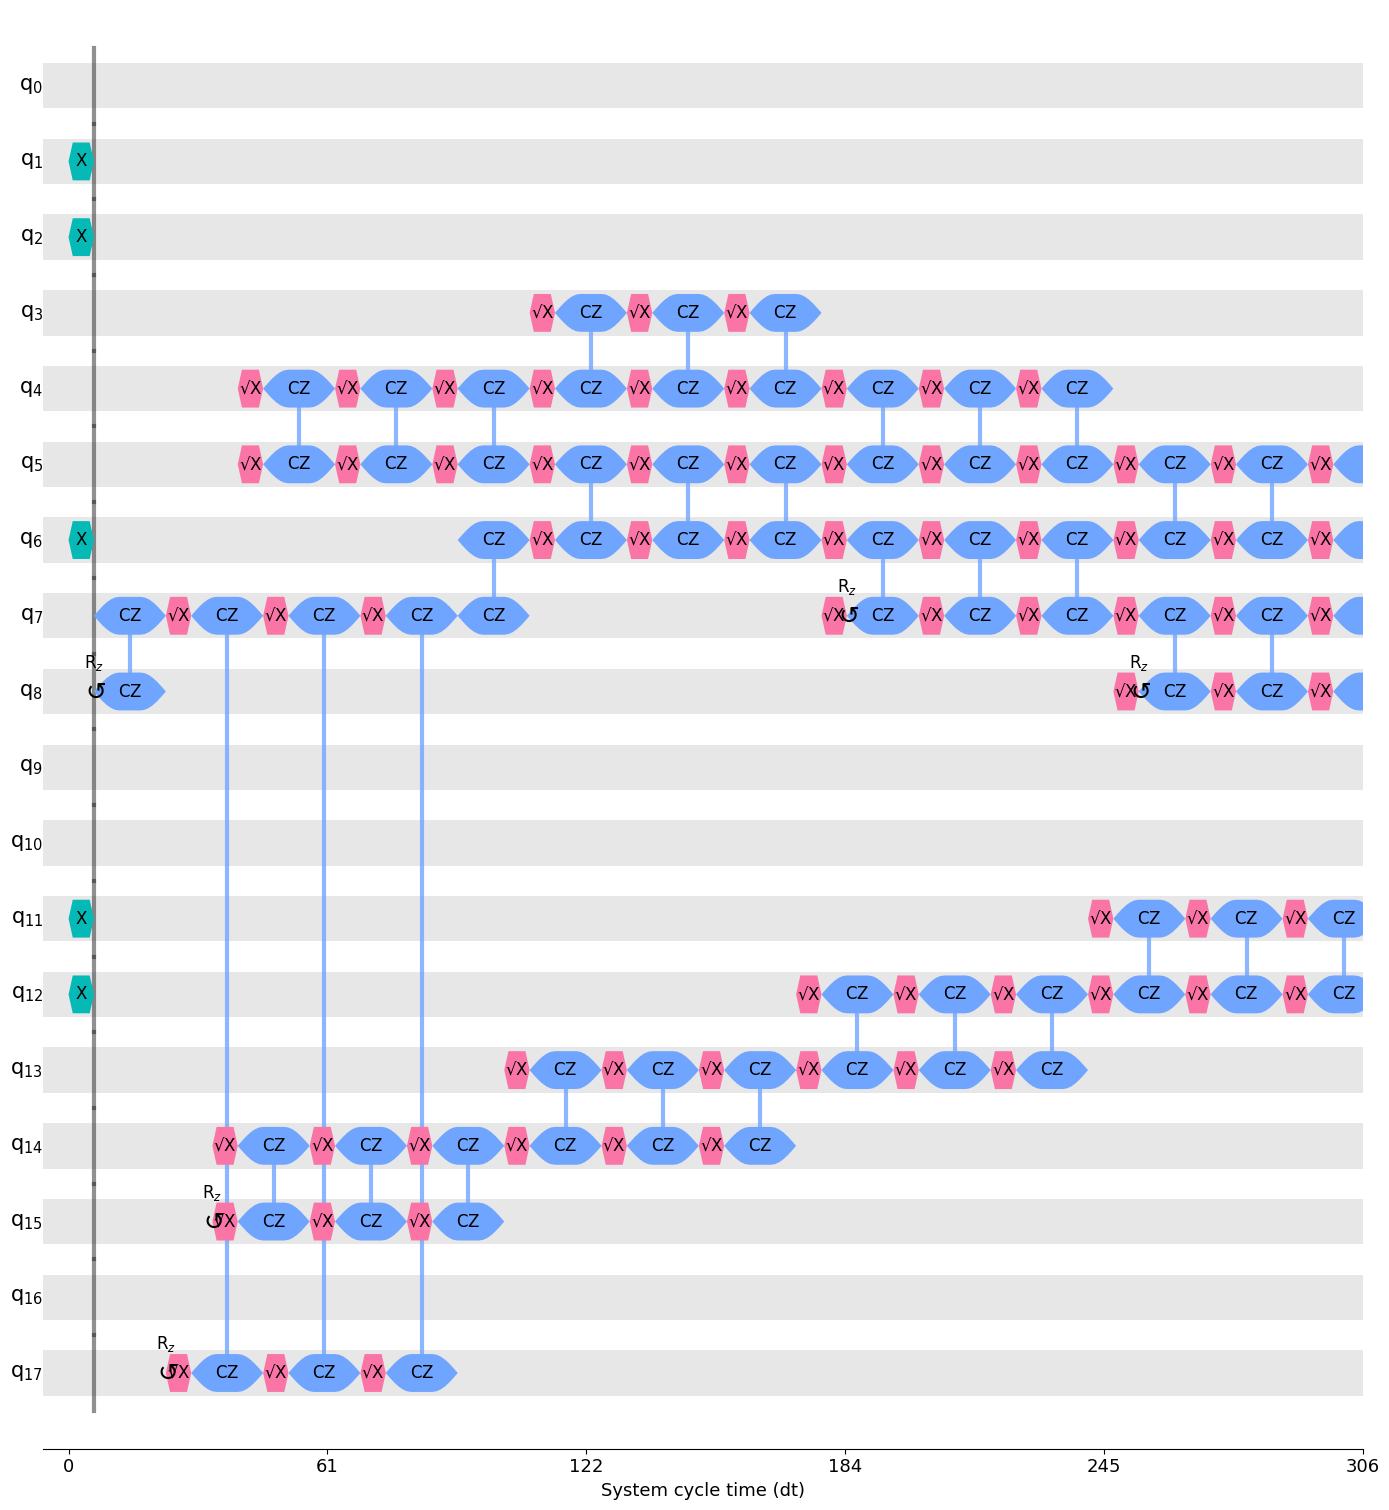

In [15]:
timeline_drawer(transpiled_qc, time_range=[0,300], target=backend.target, show_idle=False)

In [16]:
# Create the Dynamical Decoupling sequence of reversible gates, let's use XGates:
durations = InstructionDurations(
    [("h", 0, 50), ("cx", [0, 1], 700), ("reset", None, 10),
     ("cx", [1, 2], 200), ("cx", [2, 3], 300),
     ("x", None, 50), ("measure", None, 1000)],
    dt=1e-7
)


# balanced X-X sequence on all qubits
dd_sequence = [XGate(), XGate()]

# Set the PassManager with the Dynamical Decoupling sequence and custom duration times
pm = PassManager([ALAPScheduleAnalysis(durations, target = backend.target),
                  PadDynamicalDecoupling(durations, dd_sequence, target = backend.target)])

opt_level = 3
pass_manager = generate_preset_pass_manager(backend = backend, optimization_level = opt_level)
isa_circuit = pass_manager.run(AddModCirc)


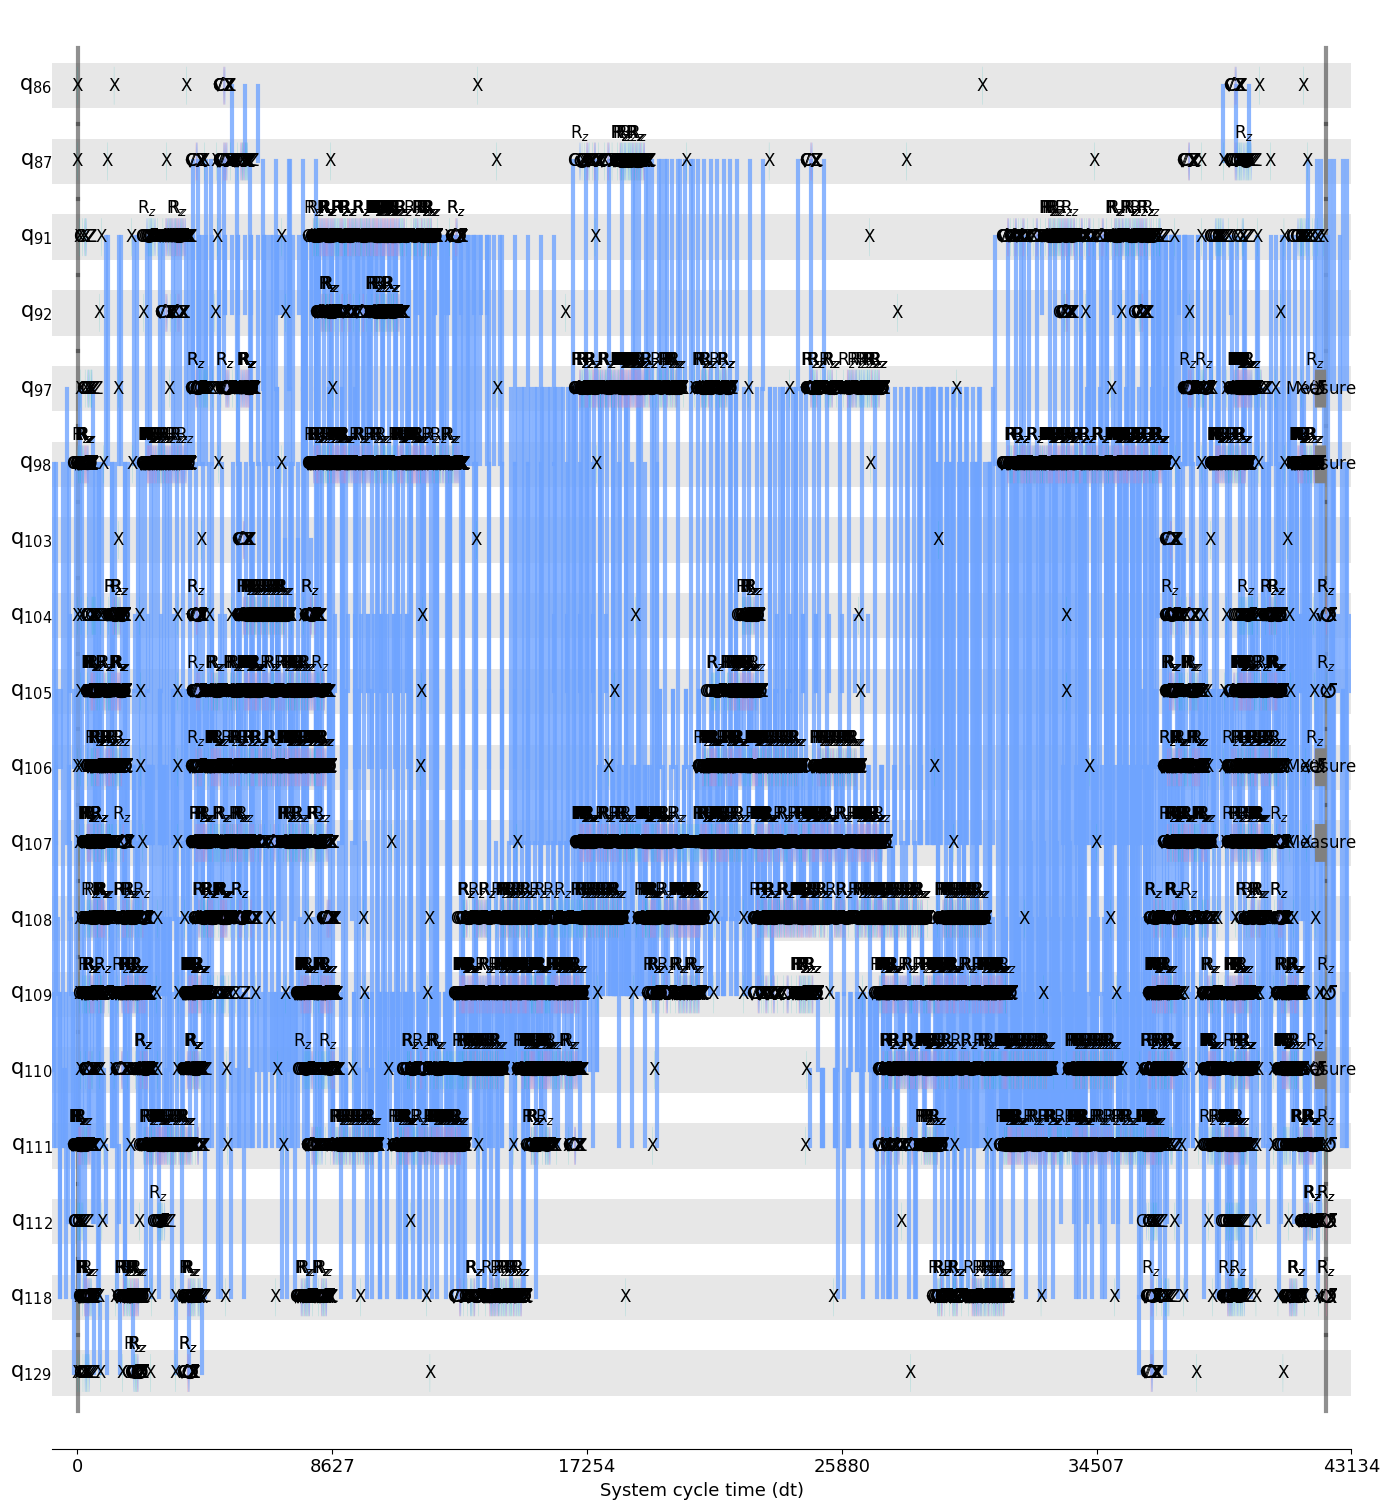

In [17]:
qc_dynamical_decoupling = pm.run(isa_circuit)
timeline_drawer(qc_dynamical_decoupling, target = backend.target, show_idle=False)

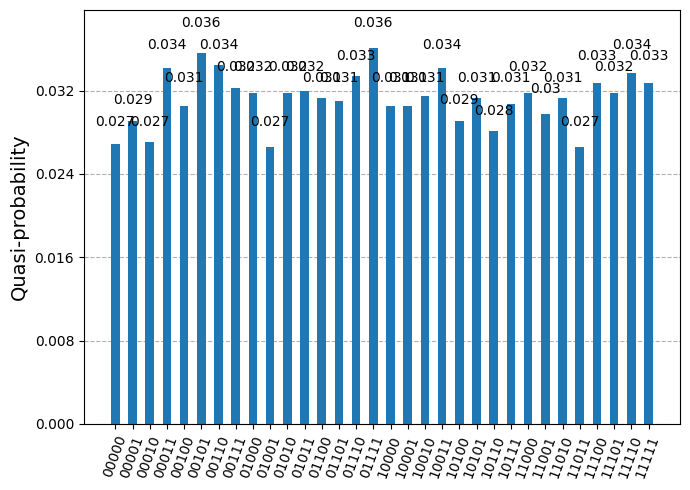

In [18]:
result = sampler.run([qc_dynamical_decoupling]).result()

# Get results for the first (and only) PUB
pub_result = result[0]
counts = pub_result.data.bclass.get_counts()
plot_distribution(counts)

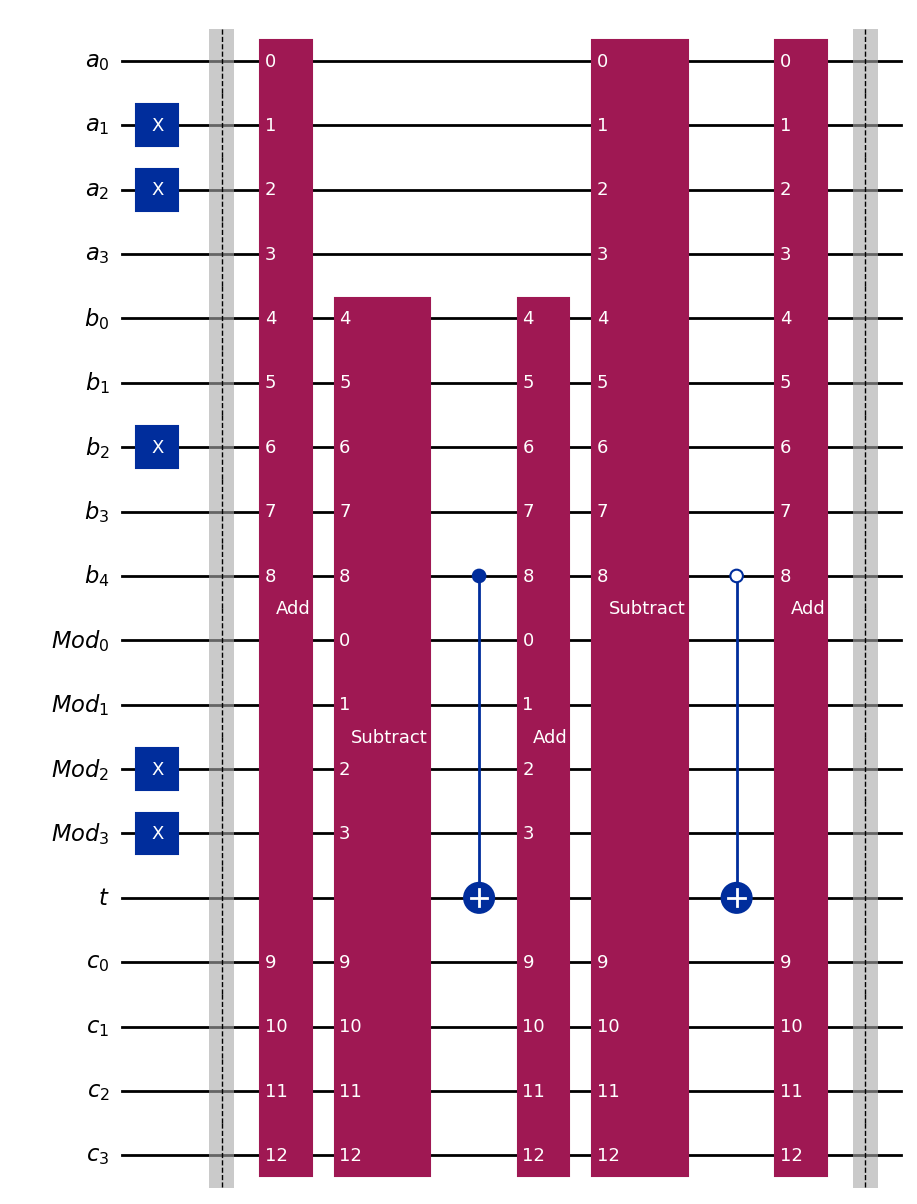

In [19]:
# Create an Add Mod M gate with n = 4 bits
n = 4
control = False
A = QuantumRegister(n,"a")
B = QuantumRegister(n + 1,"b")
M = QuantumRegister(n,"Mod")
T = QuantumRegister(1,"t")
C = QuantumRegister(n,"c")

seed_a = '0110' # Value (6) to store in register a
seed_b = '00100' # Value (4) to store in register b
                # Expected sum: 6 + 4 mod 12 = 10 = |01010>
seed_m = '01100' # Value (12) of M for arithmetic mod M

AddModCirc = QuantumCircuit(A,B,M,T,C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        AddModCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        AddModCirc.x(B[bit])

# Repeat the process for the initial value of register b
seed_m = list(map(int, list(seed_m)))[::-1] 

# encode the value of register b
for bit in range(len(seed_m)):
    if seed_m[bit] == 1:
        AddModCirc.x(M[bit])

AddModCirc.barrier()

# Create the Add, Controlled Add, and Sub gates:
AddGate = create_add_gate(n, control)
control = True
CtlAddGate = create_add_gate(n, control)
SubGate = create_subtraction_gate(n)

AddModCirc.append(AddGate,A[:]+B[:]+C[:]) # First sum A + B and save it in B
AddModCirc.append(SubGate,M[:]+B[:]+C[:]) # Subtract M from B
AddModCirc.cx(B[n],T) # Toggle T when underflow
AddModCirc.append(CtlAddGate,T[:]+M[:]+B[:]+C[:]) # When underflow, add M back to B
AddModCirc.append(SubGate,A[:]+B[:]+C[:]) # Subtract A froM B again
AddModCirc.cx(B[n],T, ctrl_state=0) # Toggle T when underflow
AddModCirc.append(AddGate, A[:]+B[:]+C[:]) # Construct final result

# Get the state of the data qubits.

AddModCirc.barrier()

#draw the circuit.
AddModCirc.draw(output="mpl")

In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session, Options, EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp, SparseObservable

#Load your IBM Quantum account(s)
service = QiskitRuntimeService(channel = "ibm_cloud")
backend = service.least_busy(operational=True, simulator=False)

In [21]:
total_qubits = len(A)+len(B)+len(M)+len(T)+len(C) 

observable = SparsePauliOp.from_sparse_list([
    ("I", [0], 15.5),
    ("Z", [4], -0.5),
    ("Z", [5], -1),
    ("Z", [6], -2),
    ("Z", [7], -4),
    ("Z", [8], -8),
], num_qubits=total_qubits)

print(observable)

SparsePauliOp(['IIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIZIIII', 'IIIIIIIIIIIIZIIIII', 'IIIIIIIIIIIZIIIIII', 'IIIIIIIIIIZIIIIIII', 'IIIIIIIIIZIIIIIIII'],
              coeffs=[15.5+0.j, -0.5+0.j, -1. +0.j, -2. +0.j, -4. +0.j, -8. +0.j])


In [22]:
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(AddModCirc)
 
isa_circuit.draw("mpl", idle_wires=False)
mapped_observable = observable.apply_layout(isa_circuit.layout)

In [23]:
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 2
estimator.options.default_shots = 5000
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observable)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d6u719k69uic73chtsag


In [24]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]
print(pub_result)

PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), evs_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), stds_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), ensemble_stds_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), evs_extrapolated=np.ndarray(<shape=(2, 4), dtype=float64>), stds_extrapolated=np.ndarray(<shape=(2, 4), dtype=float64>)), metadata={'shots': 5024, 'target_precision': 0.01414213562373095, 'circuit_metadata': {}, 'resilience': {'zne': {'extrapolator': 'multiple'}}, 'num_randomizations': 32})


In [25]:
print(f"Expectation value: {pub_result.data.evs}")

Expectation value: 15.269024776458997


In [26]:
# Instantiate the QASM simulator from the Aer provider
backend_simulator = QasmSimulator()

In [27]:
# Transpile the circuit
transpiled_qc = transpile(AddModCirc, backend_simulator)
mapped_observable = observable.apply_layout(transpiled_qc.layout)

In [31]:
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend_simulator)
#estimator.options.resilience_level = 2
estimator.options.default_shots = 5000
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(transpiled_qc, mapped_observable)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: 916a814f-9d98-4389-9eb0-c67453b9c796


In [32]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]
print(pub_result)

PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.float64(0.0)), metadata={'target_precision': 0.01414213562373095, 'shots': 5000, 'circuit_metadata': {}})


In [33]:
print(f"Expectation value: {pub_result.data.evs}")

Expectation value: 10.0
